In [9]:
!nvidia-smi

Mon May 25 14:36:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             27W /   70W |    8569MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Harassment and Suspicious Activity Detection
This notebook trains two models for the pipeline:
1. **YOLOv8**: For object detection and localization (detecting harassment/violence/people).
2. **VGG16**: For image classification on the cropped regions to double-check or classify behaviors.

**Classes mapping:**
* `0`: Harassment (includes harassment, suspicious, kidnap, inappropriate touch)
* `1`: Violence
* `2`: non_Harassment (normal images, generic people)


In [3]:
import os
yolo_img_dir = r"/content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Combined_YOLO_Dataset/images"
vgg_crop_dir = r"/content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Combined_VGG16_Dataset"

def count_files(dir_path):
    if not os.path.exists(dir_path): return 0
    return sum([len(files) for r, d, files in os.walk(dir_path)])

print("Total YOLO Images:", count_files(yolo_img_dir))
print("Total VGG16 Crops extracted:", count_files(vgg_crop_dir))


Total YOLO Images: 3502
Total VGG16 Crops extracted: 4564


# Create a file to save the models

In [4]:
import os
from google.colab import drive

save_path = '/content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models'
os.makedirs(save_path, exist_ok=True)

print(f"The folder was created: {save_path}")
print(f"The models will be saved here after training:{save_path} ")

The folder was created: /content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models
The models will be saved here after training:/content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models 


## 1. YOLOv8 Training (Object Detection)
We will use the Ultralytics YOLOv8 library. Ensure `ultralytics` is installed (`!pip install ultralytics`).

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model
model = YOLO('yolov8n.pt')

# Define the path to the combined data.yaml
data_yaml_path = r"/content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Combined_YOLO_Dataset/data.yaml"

# Train the model
# You can adjust epochs, batch, and imgsz according to your GPU capacity
results = model.train(data=data_yaml_path, epochs=100, imgsz=640, batch=16, project=save_path , name='yolov8_run')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Combined_YOLO_Dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, 

## 2. Data Augmentation and VGG16 Training (Classification)
We apply Data Augmentation using `ImageDataGenerator` on our extracted cropped bounding boxes.
This makes the VGG16 model robust to varied lighting, orientation, and zoom.

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# Data Augmentation Setup
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_dir = os.path.join(vgg_crop_dir, 'train')
val_dir = os.path.join(vgg_crop_dir, 'val')

# Note: Ensure that target_size matches VGG16 input format
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 3713 images belonging to 3 classes.
Found 558 images belonging to 3 classes.


In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG16 base model, excluding the top classifying layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers for our 3 classes
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x) # 3 Classes: Harassment, Violence, non_Harassment

vgg_model = Model(inputs=base_model.input, outputs=output)

vgg_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

vgg_model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,138,243 (80.64 MB)

 Trainable params: 6,423,555 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [12]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("Available GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
Available GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

# Save path
vgg_model_path = os.path.join(
    save_path,
    'vgg16_best_model.keras'
)

# Save best model only
checkpoint = ModelCheckpoint(
    filepath=vgg_model_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',
    verbose=1
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train model
history = vgg_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=[
        checkpoint,
        early_stop
    ]
)

print(f"\n✅ The best VGG16 model was saved in:\n{vgg_model_path}")

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8389 - loss: 0.3751
Epoch 1: val_loss improved from None to 0.33592, saving model to /content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models/vgg16_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models/vgg16_best_model.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 75s 637ms/step - accuracy: 0.8271 - loss: 0.3948 - val_accuracy: 0.8369 - val_loss: 0.3359
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.8311 - loss: 0.3911
Epoch 2: val_loss improved from 0.33592 to 0.32980, saving model to /content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models/vgg16_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/Final (Harassment)/Trained_Models/vgg16_best_model.keras
117/117 ━━━━━━━━━━━━━━━━━━━━ 72s 613ms/step - accuracy: 0.8309 - loss: 0.3870 - val_accuracy: 0.8548 - val_loss: 0.

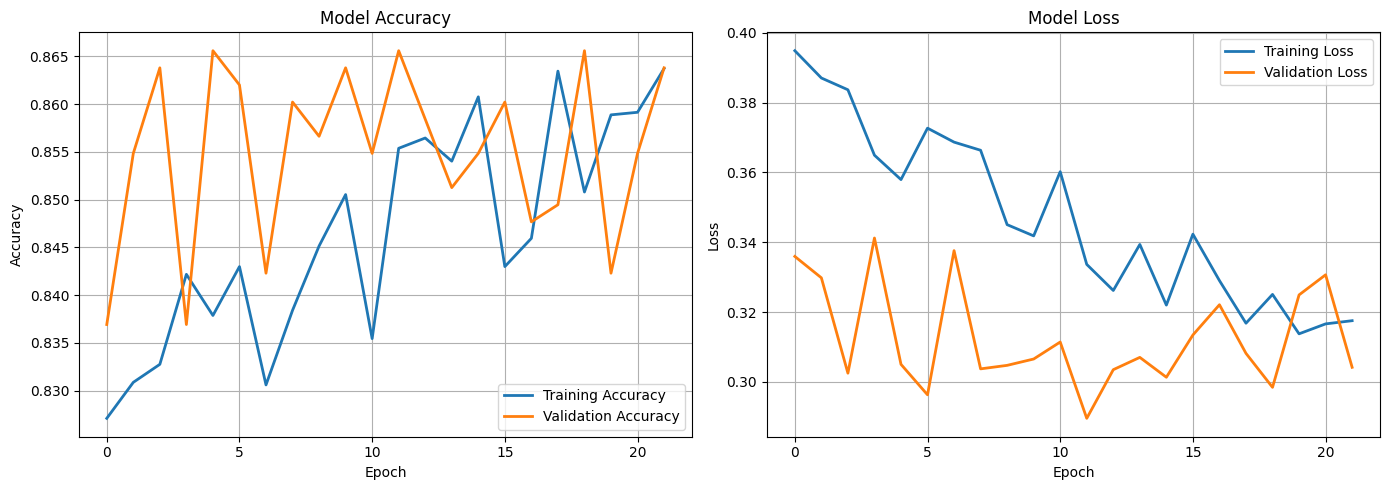

In [15]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(14, 5))

# ================= Accuracy =================
plt.subplot(1, 2, 1)

plt.plot(history.history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ================= Loss =================
plt.subplot(1, 2, 2)

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Layout
plt.tight_layout()

# Show plots
plt.show()

## 3. Models Testing

In [3]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from ultralytics import YOLO

# 1. Model Paths (Local)
YOLO_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\yolov8_run\weights\best.pt"
VGG_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\vgg16_best_model.keras"

print("Loading Custom YOLOv8 Model...")
yolo_model = YOLO(YOLO_MODEL_PATH)

print("Loading Custom VGG16 Model...")
vgg_model = load_model(VGG_MODEL_PATH)

print("Loading Pose Model...")
pose_model = YOLO('yolov8n-pose.pt') 

def check_physical_contact(pose_frame_res, current_box_coords):
    """
    A smart geometric function that measures the distance between hands and bodies 
    using a 'dynamic' distance threshold that adapts to the person's size in the frame.
    """
    if len(pose_frame_res) == 0 or pose_frame_res[0].keypoints is None:
        return False
        
    cx1, cy1, cx2, cy2 = current_box_coords
    box_width = cx2 - cx1
    
    # --- Dynamic Threshold ---
    # Take 15% of the person's bounding box width as the allowed contact distance
    # with a minimum of 20 pixels and a maximum of 60 pixels to ensure accuracy at all distances.
    threshold = max(20, min(60, int(box_width * 0.15)))
        
    kpts = pose_frame_res[0].keypoints.xy.cpu().numpy() 
    confs = pose_frame_res[0].keypoints.conf.cpu().numpy() 
    num_people = len(kpts)
    
    if num_people < 2:
        return False
        
    for i in range(num_people):
        hands = []
        # Increased hand detection confidence to 65% to prevent the model from 
        # "guessing" hand locations if they are occluded or out of frame.
        # Keypoints 9 and 10 represent the wrists in YOLOv8 Pose.
        if confs[i][9] > 0.65: hands.append(kpts[i][9])
        if confs[i][10] > 0.65: hands.append(kpts[i][10])
        
        if len(hands) == 0:
            continue
            
        for j in range(num_people):
            if i == j: continue 
                
            body_parts = []
            # Torso keypoints (Shoulders and Hips) with high confidence (60%)
            for bp_idx in range(5, 13):
                if confs[j][bp_idx] > 0.60:
                    body_parts.append(kpts[j][bp_idx])
                    
            # Measure dynamic distance
            for hand in hands:
                for bp in body_parts:
                    dist = np.linalg.norm(hand - bp)
                    if dist < threshold:
                        return True 
                        
    return False

def predict_and_draw(img):
    # 1. Increased YOLO confidence to 60% to prevent detecting pockets/shadows as fake people
    results = yolo_model(img, conf=0.6, verbose=False)
    
    # 2. Use the global Pose model to count ONLY "Real People" in the camera to prevent hallucinations
    pose_frame_res = pose_model(img, conf=0.6, verbose=False)
    real_people_boxes = pose_frame_res[0].boxes if len(pose_frame_res) > 0 else []
    total_real_people = len(real_people_boxes)
    
    HARASSMENT_THRESHOLD = 0.85
    VIOLENCE_THRESHOLD = 0.80
    
    all_yolo_boxes = results[0].boxes if len(results) > 0 else []
        
    for box in all_yolo_boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        current_coords = (x1, y1, x2, y2)
        
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
        if x2 <= x1 or y2 <= y1: continue
            
        crop = img[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_normalized = crop_resized / 255.0
        crop_expanded = np.expand_dims(crop_normalized, axis=0)
        
        vgg_preds = vgg_model.predict(crop_expanded, verbose=0)[0]
        harassment_prob, violence_prob, non_harassment_prob = vgg_preds[0], vgg_preds[1], vgg_preds[2]
        
        # --- Check for physical contact using the dynamic distance logic ---
        is_touching = check_physical_contact(pose_frame_res, current_coords)
        
        if harassment_prob >= HARASSMENT_THRESHOLD:
            if total_real_people < 2:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                class_name = 'Harassment'
                conf = harassment_prob
                label_text = f"Harassment Detected!: {conf*100:.1f}%"
                
        elif violence_prob >= VIOLENCE_THRESHOLD:
            if total_real_people < 2:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                class_name = 'Violence'
                conf = violence_prob
                label_text = f"Violence: {conf*100:.1f}%"
        else:
            class_name = 'non_Harassment'
            conf = non_harassment_prob
            if total_real_people < 2:
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                label_text = f"Normal: {conf*100:.1f}%"
        
        # --- Draw Bounding Boxes ---
        if class_name == 'Harassment' or class_name == 'Violence':
            action_box_drawn = False
            if len(pose_frame_res) > 0 and pose_frame_res[0].keypoints is not None:
                kpts = pose_frame_res[0].keypoints.xy.cpu().numpy() 
                confs = pose_frame_res[0].keypoints.conf.cpu().numpy()
                
                action_points = []
                for i in range(len(kpts)):
                    for idx in [7, 8, 9, 10]:
                        if confs[i][idx] > 0.65: # Draw action box only if hand is clearly visible
                            px, py = int(kpts[i][idx][0]), int(kpts[i][idx][1])
                            if px >= x1 and px <= x2 and py >= y1 and py <= y2:
                                action_points.append((px, py))
                            
                if len(action_points) > 0:
                    action_points = np.array(action_points)
                    ax1, ay1 = int(np.min(action_points[:, 0])) - 40, int(np.min(action_points[:, 1])) - 40
                    ax2, ay2 = int(np.max(action_points[:, 0])) + 40, int(np.max(action_points[:, 1])) + 40
                    ax1, ay1 = max(0, ax1), max(0, ay1)
                    ax2, ay2 = min(img.shape[1], ax2), min(img.shape[0], ay2)
                    
                    color_box = (0, 0, 255) if class_name == 'Harassment' else (0, 165, 255)
                    cv2.rectangle(img, (ax1, ay1), (ax2, ay2), color_box, 3)
                    (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
                    text_y = ay1 - 5 if ay1 - 25 > 0 else ay1 + h + 10
                    cv2.rectangle(img, (ax1, text_y - h - 5), (ax1 + w, text_y + 5), color_box, -1)
                    cv2.putText(img, label_text, (ax1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
                    action_box_drawn = True
            
            if not action_box_drawn:
                color_box = (0, 0, 255) if class_name == 'Harassment' else (0, 165, 255)
                cv2.rectangle(img, (x1, y1), (x2, y2), color_box, 2)
                cv2.putText(img, label_text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_box, 2)
        else:
            color = (0, 255, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 25), (x1 + w, y1), (0, 0, 0), -1)
            cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            
    return img

def test_on_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not access the webcam.")
        return
        
    print("Webcam started successfully! Press 'q' to exit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        result_frame = predict_and_draw(frame)
        cv2.imshow('Smart Harassment Detection', result_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

# Run the webcam
test_on_webcam()


Loading Custom YOLOv8 Model...
Loading Custom VGG16 Model...
Loading Pose Model...
Webcam started successfully! Press 'q' to exit.


In [5]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from ultralytics import YOLO

# 1. Model Paths
YOLO_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\yolov8_run\weights\best.pt"
VGG_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\vgg16_best_model.keras"

print("Loading Custom YOLOv8 Model...")
yolo_model = YOLO(YOLO_MODEL_PATH)

print("Loading Custom VGG16 Model...")
vgg_model = load_model(VGG_MODEL_PATH)

print("Loading Pose Model...")
pose_model = YOLO('yolov8n-pose.pt') 

def get_contact_info(pose_frame_res, current_box_coords):
    """
    Advanced function to determine if a person is the 'Aggressor' or 'Victim',
    and returns the exact (x, y) coordinates of the physical contact.
    """
    if len(pose_frame_res) == 0 or pose_frame_res[0].keypoints is None:
        return False, "None", []
        
    kpts = pose_frame_res[0].keypoints.xy.cpu().numpy() 
    confs = pose_frame_res[0].keypoints.conf.cpu().numpy()
    pose_boxes = pose_frame_res[0].boxes.xyxy.cpu().numpy()
    num_people = len(kpts)
    
    if num_people < 2:
        return False, "None", []
        
    # Find the Skeleton that belongs to the current bounding box
    cx1, cy1, cx2, cy2 = current_box_coords
    current_center = ((cx1 + cx2) / 2, (cy1 + cy2) / 2)
    
    best_i = -1
    min_dist = float('inf')
    for i in range(num_people):
        px1, py1, px2, py2 = pose_boxes[i]
        p_center = ((px1 + px2) / 2, (py1 + py2) / 2)
        dist = (current_center[0] - p_center[0])**2 + (current_center[1] - p_center[1])**2
        if dist < min_dist:
            min_dist = dist
            best_i = i
            
    if best_i == -1:
        return False, "None", []
        
    # Dynamic distance threshold
    px1, py1, px2, py2 = pose_boxes[best_i]
    box_width = px2 - px1
    threshold = max(20, min(60, int(box_width * 0.15)))
    
    is_aggressor = False
    is_victim = False
    contact_points = []
    
    # 1. Is Current Person the Aggressor? (Their hands touching others' bodies)
    hands_i = []
    if confs[best_i][9] > 0.65: hands_i.append(kpts[best_i][9])
    if confs[best_i][10] > 0.65: hands_i.append(kpts[best_i][10])
    
    for j in range(num_people):
        if best_i == j: continue
        body_parts_j = []
        # Check all body parts of the other person (except hands)
        for bp_idx in range(17):
            if bp_idx in [9, 10]: continue 
            if confs[j][bp_idx] > 0.60:
                body_parts_j.append(kpts[j][bp_idx])
                
        for hand in hands_i:
            for bp in body_parts_j:
                if np.linalg.norm(hand - bp) < threshold:
                    is_aggressor = True
                    contact_points.append(hand)
                    
    # 2. Is Current Person the Victim? (Others' hands touching their body)
    body_parts_i = []
    for bp_idx in range(17):
        if bp_idx in [9, 10]: continue
        if confs[best_i][bp_idx] > 0.60:
            body_parts_i.append(kpts[best_i][bp_idx])
            
    for j in range(num_people):
        if best_i == j: continue
        hands_j = []
        if confs[j][9] > 0.65: hands_j.append(kpts[j][9])
        if confs[j][10] > 0.65: hands_j.append(kpts[j][10])
        
        for hand in hands_j:
            for bp in body_parts_i:
                if np.linalg.norm(hand - bp) < threshold:
                    is_victim = True
                    contact_points.append(hand)
                    
    role = "None"
    if is_aggressor and is_victim:
        role = "Mutual (Both)"
    elif is_aggressor:
        role = "Aggressor"
    elif is_victim:
        role = "Victim"
        
    is_touching = (is_aggressor or is_victim)
    
    return is_touching, role, contact_points

def predict_and_draw(img):
    results = yolo_model(img, conf=0.6, verbose=False)
    pose_frame_res = pose_model(img, conf=0.6, verbose=False)
    
    real_people_boxes = pose_frame_res[0].boxes if len(pose_frame_res) > 0 else []
    total_real_people = len(real_people_boxes)
    
    HARASSMENT_THRESHOLD = 0.85
    VIOLENCE_THRESHOLD = 0.80
    
    all_yolo_boxes = results[0].boxes if len(results) > 0 else []
        
    for box in all_yolo_boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        current_coords = (x1, y1, x2, y2)
        
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
        if x2 <= x1 or y2 <= y1: continue
            
        crop = img[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_normalized = crop_resized / 255.0
        crop_expanded = np.expand_dims(crop_normalized, axis=0)
        
        vgg_preds = vgg_model.predict(crop_expanded, verbose=0)[0]
        harassment_prob, violence_prob, non_harassment_prob = vgg_preds[0], vgg_preds[1], vgg_preds[2]
        
        # --- Advanced Role & Contact Detection ---
        is_touching, role, contact_pts = get_contact_info(pose_frame_res, current_coords)
        
        if harassment_prob >= HARASSMENT_THRESHOLD:
            if total_real_people < 2:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                class_name = 'Harassment'
                conf = harassment_prob
                # Set label based on Forensic Role!
                if role == "Aggressor":
                    label_text = f"Aggressor: {conf*100:.1f}%"
                elif role == "Victim":
                    label_text = f"Victim: {conf*100:.1f}%"
                else:
                    label_text = f"Harassment: {conf*100:.1f}%"
                    
        elif violence_prob >= VIOLENCE_THRESHOLD:
            if total_real_people < 2:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                class_name = 'Violence'
                conf = violence_prob
                label_text = f"Violence: {conf*100:.1f}%"
        else:
            class_name = 'non_Harassment'
            conf = non_harassment_prob
            if total_real_people < 2:
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                label_text = f"Normal: {conf*100:.1f}%"
        
        # --- Drawing Logic ---
        if class_name == 'Harassment':
            # Box color based on role
            if role == "Aggressor" or role == "Mutual (Both)":
                color_box = (0, 0, 255) # Red for Aggressor
            else:
                color_box = (0, 165, 255) # Orange for Victim
                
            cv2.rectangle(img, (x1, y1), (x2, y2), color_box, 3)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            text_y = y1 - 5 if y1 - 25 > 0 else y1 + h + 10
            cv2.rectangle(img, (x1, text_y - h - 5), (x1 + w, text_y + 5), color_box, -1)
            cv2.putText(img, label_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            # --- Draw the Exact Point of Contact! ---
            for pt in contact_pts:
                px, py = int(pt[0]), int(pt[1])
                # Draw a glowing yellow/red target on the hand
                cv2.circle(img, (px, py), 15, (0, 255, 255), -1) # Yellow core
                cv2.circle(img, (px, py), 25, (0, 0, 255), 3) # Red border
                cv2.putText(img, "Contact!", (px - 30, py - 35), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                
        elif class_name == 'Violence':
            color_box = (0, 165, 255)
            cv2.rectangle(img, (x1, y1), (x2, y2), color_box, 2)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            text_y = y1 - 5 if y1 - 25 > 0 else y1 + h + 10
            cv2.rectangle(img, (x1, text_y - h - 5), (x1 + w, text_y + 5), color_box, -1)
            cv2.putText(img, label_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        else:
            color = (0, 255, 0) # Green for Normal
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 25), (x1 + w, y1), (0, 0, 0), -1)
            cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            
    return img

def test_on_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not access the webcam.")
        return
        
    print("Webcam started successfully! Press 'q' to exit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        result_frame = predict_and_draw(frame)
        cv2.imshow('Smart Forensic Harassment Detection', result_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

test_on_webcam()


Loading Custom YOLOv8 Model...
Loading Custom VGG16 Model...
Loading Pose Model...
Webcam started successfully! Press 'q' to exit.


In [6]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from ultralytics import YOLO

# 1. Model Paths
YOLO_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\yolov8_run\weights\best.pt"
VGG_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\vgg16_best_model.keras"

print("Loading Custom YOLOv8 Model...")
yolo_model = YOLO(YOLO_MODEL_PATH)

print("Loading Custom VGG16 Model...")
vgg_model = load_model(VGG_MODEL_PATH)

print("Loading Pose Model...")
pose_model = YOLO('yolov8n-pose.pt') 

def get_contact_info(pose_frame_res, current_box_coords):
    if len(pose_frame_res) == 0 or pose_frame_res[0].keypoints is None:
        return False, "None", []
        
    kpts = pose_frame_res[0].keypoints.xy.cpu().numpy() 
    confs = pose_frame_res[0].keypoints.conf.cpu().numpy()
    pose_boxes = pose_frame_res[0].boxes.xyxy.cpu().numpy()
    num_people = len(kpts)
    
    if num_people < 2:
        return False, "None", []
        
    cx1, cy1, cx2, cy2 = current_box_coords
    current_center = ((cx1 + cx2) / 2, (cy1 + cy2) / 2)
    
    best_i = -1
    min_dist = float('inf')
    for i in range(num_people):
        px1, py1, px2, py2 = pose_boxes[i]
        p_center = ((px1 + px2) / 2, (py1 + py2) / 2)
        dist = (current_center[0] - p_center[0])**2 + (current_center[1] - p_center[1])**2
        if dist < min_dist:
            min_dist = dist
            best_i = i
            
    if best_i == -1:
        return False, "None", []
        
    # زيادة السماحية إلى 20% لتثبيت التحديد أثناء الحركة
    px1, py1, px2, py2 = pose_boxes[best_i]
    box_width = px2 - px1
    threshold = max(30, min(85, int(box_width * 0.20)))
    
    is_aggressor = False
    is_victim = False
    contact_points = []
    
    # 1. Is Current Person the Aggressor? 
    hands_i = []
    # تخفيض الدقة لـ 50% لتجنب التقطيع عند الحركة السريعة
    if confs[best_i][9] > 0.50: hands_i.append(kpts[best_i][9])
    if confs[best_i][10] > 0.50: hands_i.append(kpts[best_i][10])
    
    for j in range(num_people):
        if best_i == j: continue
        body_parts_j = []
        for bp_idx in range(17):
            if bp_idx in [9, 10]: continue 
            if confs[j][bp_idx] > 0.50:
                body_parts_j.append(kpts[j][bp_idx])
                
        for hand in hands_i:
            for bp in body_parts_j:
                if np.linalg.norm(hand - bp) < threshold:
                    is_aggressor = True
                    contact_points.append(hand)
                    
    # 2. Is Current Person the Victim?
    body_parts_i = []
    for bp_idx in range(17):
        if bp_idx in [9, 10]: continue
        if confs[best_i][bp_idx] > 0.50:
            body_parts_i.append(kpts[best_i][bp_idx])
            
    for j in range(num_people):
        if best_i == j: continue
        hands_j = []
        if confs[j][9] > 0.50: hands_j.append(kpts[j][9])
        if confs[j][10] > 0.50: hands_j.append(kpts[j][10])
        
        for hand in hands_j:
            for bp in body_parts_i:
                if np.linalg.norm(hand - bp) < threshold:
                    is_victim = True
                    contact_points.append(hand)
                    
    role = "None"
    if is_aggressor and is_victim:
        role = "Mutual (Both)"
    elif is_aggressor:
        role = "Aggressor"
    elif is_victim:
        role = "Victim"
        
    is_touching = (is_aggressor or is_victim)
    
    return is_touching, role, contact_points

def predict_and_draw(img):
    results = yolo_model(img, conf=0.55, verbose=False)
    pose_frame_res = pose_model(img, conf=0.55, verbose=False)
    
    real_people_boxes = pose_frame_res[0].boxes if len(pose_frame_res) > 0 else []
    total_real_people = len(real_people_boxes)
    
    # تخفيض عتبة VGG إلى 70% لأن جدار الحماية (التلامس) سيتكفل بالباقي
    HARASSMENT_THRESHOLD = 0.70
    VIOLENCE_THRESHOLD = 0.70
    
    all_yolo_boxes = results[0].boxes if len(results) > 0 else []
        
    for box in all_yolo_boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        current_coords = (x1, y1, x2, y2)
        
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
        if x2 <= x1 or y2 <= y1: continue
            
        crop = img[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_normalized = crop_resized / 255.0
        crop_expanded = np.expand_dims(crop_normalized, axis=0)
        
        vgg_preds = vgg_model.predict(crop_expanded, verbose=0)[0]
        harassment_prob, violence_prob, non_harassment_prob = vgg_preds[0], vgg_preds[1], vgg_preds[2]
        
        is_touching, role, contact_pts = get_contact_info(pose_frame_res, current_coords)
        
        if harassment_prob >= HARASSMENT_THRESHOLD:
            if total_real_people < 2:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                class_name = 'Harassment'
                conf = harassment_prob
                if role == "Aggressor":
                    label_text = f"Aggressor: {conf*100:.1f}%"
                elif role == "Victim":
                    label_text = f"Victim: {conf*100:.1f}%"
                else:
                    label_text = f"Harassment: {conf*100:.1f}%"
                    
        elif violence_prob >= VIOLENCE_THRESHOLD:
            if total_real_people < 2:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                class_name = 'non_Harassment'
                conf = non_harassment_prob
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                class_name = 'Violence'
                conf = violence_prob
                label_text = f"Violence: {conf*100:.1f}%"
        else:
            class_name = 'non_Harassment'
            conf = non_harassment_prob
            if total_real_people < 2:
                label_text = f"Normal (Alone): {conf*100:.1f}%"
            elif not is_touching:
                label_text = f"Normal (No Touch): {conf*100:.1f}%"
            else:
                label_text = f"Normal: {conf*100:.1f}%"
        
        if class_name == 'Harassment':
            if role == "Aggressor" or role == "Mutual (Both)":
                color_box = (0, 0, 255) 
            else:
                color_box = (0, 165, 255) 
                
            cv2.rectangle(img, (x1, y1), (x2, y2), color_box, 3)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            text_y = y1 - 5 if y1 - 25 > 0 else y1 + h + 10
            cv2.rectangle(img, (x1, text_y - h - 5), (x1 + w, text_y + 5), color_box, -1)
            cv2.putText(img, label_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            for pt in contact_pts:
                px, py = int(pt[0]), int(pt[1])
                cv2.circle(img, (px, py), 15, (0, 255, 255), -1) 
                cv2.circle(img, (px, py), 25, (0, 0, 255), 3) 
                cv2.putText(img, "Contact!", (px - 30, py - 35), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                
        elif class_name == 'Violence':
            color_box = (0, 165, 255)
            cv2.rectangle(img, (x1, y1), (x2, y2), color_box, 2)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            text_y = y1 - 5 if y1 - 25 > 0 else y1 + h + 10
            cv2.rectangle(img, (x1, text_y - h - 5), (x1 + w, text_y + 5), color_box, -1)
            cv2.putText(img, label_text, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        else:
            color = (0, 255, 0)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(img, (x1, y1 - 25), (x1 + w, y1), (0, 0, 0), -1)
            cv2.putText(img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
            
    return img

def test_on_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not access the webcam.")
        return
        
    print("Webcam started successfully! Press 'q' to exit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        result_frame = predict_and_draw(frame)
        cv2.imshow('Smart Forensic Harassment Detection', result_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

test_on_webcam()


Loading Custom YOLOv8 Model...
Loading Custom VGG16 Model...
Loading Pose Model...
Webcam started successfully! Press 'q' to exit.


## 4. The 4 Models Testing

In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from ultralytics import YOLO

# 1. Model Paths
YOLO_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\yolov8_run\weights\best.pt"
VGG_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\vgg16_best_model.keras"
WEAPON_MODEL_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\Weapon\best.pt"

print("Loading Custom YOLOv8 Person Model...")
yolo_model = YOLO(YOLO_MODEL_PATH)

print("Loading Custom VGG16 Model...")
vgg_model = load_model(VGG_MODEL_PATH)

print("Loading Pose Model...")
pose_model = YOLO('yolov8n-pose.pt') 

print("Loading Weapon Detection Model...")
weapon_model = YOLO(WEAPON_MODEL_PATH)

def get_weapon_info(pose_frame_res, weapon_boxes_raw, current_box_coords):
    if len(weapon_boxes_raw) == 0:
        return False, "None", []
        
    # --- Safety Check ---
    if len(pose_frame_res) == 0 or pose_frame_res[0].keypoints is None or pose_frame_res[0].keypoints.conf is None:
        return False, "None", []
        
    kpts = pose_frame_res[0].keypoints.xy.cpu().numpy() 
    confs = pose_frame_res[0].keypoints.conf.cpu().numpy()
    pose_boxes_xyxy = pose_frame_res[0].boxes.xyxy.cpu().numpy()
    num_people = len(kpts)
    
    cx1, cy1, cx2, cy2 = current_box_coords
    current_center = ((cx1 + cx2) / 2, (cy1 + cy2) / 2)
    
    best_i = -1
    min_dist = float('inf')
    for i in range(num_people):
        px1, py1, px2, py2 = pose_boxes_xyxy[i]
        p_center = ((px1 + px2) / 2, (py1 + py2) / 2)
        dist = (current_center[0] - p_center[0])**2 + (current_center[1] - p_center[1])**2
        if dist < min_dist:
            min_dist = dist
            best_i = i
            
    if best_i == -1:
        return False, "None", []
        
    px1, py1, px2, py2 = pose_boxes_xyxy[best_i]
    box_width = px2 - px1
    threshold = max(30, min(90, int(box_width * 0.25))) 
    
    is_aggressor = False
    is_victim = False
    weapons_to_draw = []
    
    for w_box in weapon_boxes_raw:
        wx1, wy1, wx2, wy2 = map(int, w_box.xyxy[0])
        w_cls_id = int(w_box.cls[0])
        w_conf = float(w_box.conf[0])
        w_name = weapon_model.names[w_cls_id] 
        
        w_center = ((wx1 + wx2) / 2, (wy1 + wy2) / 2)
        
        hands_i = []
        if confs[best_i][9] > 0.40: hands_i.append(kpts[best_i][9])
        if confs[best_i][10] > 0.40: hands_i.append(kpts[best_i][10])
        
        holding = False
        for hand in hands_i:
            if np.linalg.norm(hand - w_center) < threshold or (wx1 <= hand[0] <= wx2 and wy1 <= hand[1] <= wy2):
                is_aggressor = True
                holding = True
                weapons_to_draw.append((wx1, wy1, wx2, wy2, w_name, w_conf))
                break
                
        if not holding:
            body_parts_i = []
            for bp_idx in range(17):
                if bp_idx in [9, 10]: continue 
                if confs[best_i][bp_idx] > 0.50:
                    body_parts_i.append(kpts[best_i][bp_idx])
                    
            for bp in body_parts_i:
                if np.linalg.norm(bp - w_center) < threshold * 1.5 or (wx1 <= bp[0] <= wx2 and wy1 <= bp[1] <= wy2):
                    is_victim = True
                    weapons_to_draw.append((wx1, wy1, wx2, wy2, w_name, w_conf))
                    break
                    
    role = "None"
    if is_aggressor:
        role = "Armed Aggressor"
    elif is_victim:
        role = "Armed Victim"
        
    is_involved = (is_aggressor or is_victim)
    return is_involved, role, weapons_to_draw

def get_contact_info(pose_frame_res, current_box_coords):
    # --- Safety Check ---
    if len(pose_frame_res) == 0 or pose_frame_res[0].keypoints is None or pose_frame_res[0].keypoints.conf is None:
        return False, "None", []
        
    kpts = pose_frame_res[0].keypoints.xy.cpu().numpy() 
    confs = pose_frame_res[0].keypoints.conf.cpu().numpy()
    pose_boxes = pose_frame_res[0].boxes.xyxy.cpu().numpy()
    num_people = len(kpts)
    
    if num_people < 2:
        return False, "None", []
        
    cx1, cy1, cx2, cy2 = current_box_coords
    current_center = ((cx1 + cx2) / 2, (cy1 + cy2) / 2)
    
    best_i = -1
    min_dist = float('inf')
    for i in range(num_people):
        px1, py1, px2, py2 = pose_boxes[i]
        p_center = ((px1 + px2) / 2, (py1 + py2) / 2)
        dist = (current_center[0] - p_center[0])**2 + (current_center[1] - p_center[1])**2
        if dist < min_dist:
            min_dist = dist
            best_i = i
            
    if best_i == -1:
        return False, "None", []
        
    px1, py1, px2, py2 = pose_boxes[best_i]
    box_width = px2 - px1
    threshold = max(30, min(85, int(box_width * 0.20)))
    
    is_aggressor = False
    is_victim = False
    contact_points = []
    
    hands_i = []
    if confs[best_i][9] > 0.50: hands_i.append(kpts[best_i][9])
    if confs[best_i][10] > 0.50: hands_i.append(kpts[best_i][10])
    
    for j in range(num_people):
        if best_i == j: continue
        body_parts_j = []
        for bp_idx in range(17):
            if bp_idx in [9, 10]: continue 
            if confs[j][bp_idx] > 0.50:
                body_parts_j.append(kpts[j][bp_idx])
                
        for hand in hands_i:
            for bp in body_parts_j:
                if np.linalg.norm(hand - bp) < threshold:
                    is_aggressor = True
                    contact_points.append(hand)
                    
    body_parts_i = []
    for bp_idx in range(17):
        if bp_idx in [9, 10]: continue
        if confs[best_i][bp_idx] > 0.50:
            body_parts_i.append(kpts[best_i][bp_idx])
            
    for j in range(num_people):
        if best_i == j: continue
        hands_j = []
        if confs[j][9] > 0.50: hands_j.append(kpts[j][9])
        if confs[j][10] > 0.50: hands_j.append(kpts[j][10])
        
        for hand in hands_j:
            for bp in body_parts_i:
                if np.linalg.norm(hand - bp) < threshold:
                    is_victim = True
                    contact_points.append(hand)
                    
    role = "None"
    if is_aggressor and is_victim:
        role = "Mutual (Both)"
    elif is_aggressor:
        role = "Aggressor"
    elif is_victim:
        role = "Victim"
        
    is_touching = (is_aggressor or is_victim)
    
    return is_touching, role, contact_points

def predict_and_draw(img):
    results = yolo_model(img, conf=0.55, verbose=False)
    pose_frame_res = pose_model(img, conf=0.55, verbose=False)
    weapon_results = weapon_model(img, conf=0.25, verbose=False) 
    
    real_people_boxes = pose_frame_res[0].boxes if len(pose_frame_res) > 0 else []
    total_real_people = len(real_people_boxes)
    weapon_boxes_raw = weapon_results[0].boxes if len(weapon_results) > 0 else []
    
    HARASSMENT_THRESHOLD = 0.70
    VIOLENCE_THRESHOLD = 0.70
    
    all_yolo_boxes = results[0].boxes if len(results) > 0 else []
        
    for box in all_yolo_boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        current_coords = (x1, y1, x2, y2)
        
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img.shape[1], x2), min(img.shape[0], y2)
        if x2 <= x1 or y2 <= y1: continue
            
        crop = img[y1:y2, x1:x2]
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        crop_resized = cv2.resize(crop_rgb, (224, 224))
        crop_normalized = crop_resized / 255.0
        crop_expanded = np.expand_dims(crop_normalized, axis=0)
        
        vgg_preds = vgg_model.predict(crop_expanded, verbose=0)[0]
        harassment_prob, violence_prob, non_harassment_prob = vgg_preds[0], vgg_preds[1], vgg_preds[2]
        
        is_touching, role_harassment, contact_pts = get_contact_info(pose_frame_res, current_coords)
        is_weapon_involved, role_weapon, weapon_coords_list = get_weapon_info(pose_frame_res, weapon_boxes_raw, current_coords)
        
        if is_weapon_involved:
            class_name = 'Armed Violence'
            if role_weapon == "Armed Aggressor":
                label_text = "Armed Aggressor!"
                color_box = (0, 0, 255)
            else:
                label_text = "Armed Victim!"
                color_box = (0, 165, 255)
                
        else:
            if harassment_prob >= HARASSMENT_THRESHOLD:
                if total_real_people < 2:
                    class_name = 'non_Harassment'
                    label_text = f"Normal (Alone): {non_harassment_prob*100:.1f}%"
                    color_box = (0, 255, 0)
                elif not is_touching:
                    class_name = 'non_Harassment'
                    label_text = f"Normal (No Touch): {non_harassment_prob*100:.1f}%"
                    color_box = (0, 255, 0)
                else:
                    class_name = 'Harassment'
                    if role_harassment == "Aggressor" or role_harassment == "Mutual (Both)":
                        label_text = f"Aggressor: {harassment_prob*100:.1f}%"
                        color_box = (0, 0, 255)
                    else:
                        label_text = f"Victim: {harassment_prob*100:.1f}%"
                        color_box = (0, 165, 255)
                        
            elif violence_prob >= VIOLENCE_THRESHOLD:
                if total_real_people < 2:
                    class_name = 'non_Harassment'
                    label_text = f"Normal (Alone): {non_harassment_prob*100:.1f}%"
                    color_box = (0, 255, 0)
                elif not is_touching:
                    class_name = 'non_Harassment'
                    label_text = f"Normal (No Touch): {non_harassment_prob*100:.1f}%"
                    color_box = (0, 255, 0)
                else:
                    class_name = 'Violence'
                    label_text = f"Violence: {violence_prob*100:.1f}%"
                    color_box = (0, 0, 255)
                    
            else:
                class_name = 'non_Harassment'
                if total_real_people < 2:
                    label_text = f"Normal (Alone): {non_harassment_prob*100:.1f}%"
                elif not is_touching:
                    label_text = f"Normal (No Touch): {non_harassment_prob*100:.1f}%"
                else:
                    label_text = f"Normal: {non_harassment_prob*100:.1f}%"
                color_box = (0, 255, 0)
        
        cv2.rectangle(img, (x1, y1), (x2, y2), color_box, 3 if class_name != 'non_Harassment' else 2)
        (w, h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        text_y = y1 - 5 if y1 - 25 > 0 else y1 + h + 10
        
        cv2.rectangle(img, (x1, text_y - h - 5) if class_name != 'non_Harassment' else (x1, y1 - 25), 
                      (x1 + w, text_y + 5) if class_name != 'non_Harassment' else (x1 + w, y1), 
                      color_box if class_name != 'non_Harassment' else (0,0,0), -1)
        
        cv2.putText(img, label_text, (x1, text_y) if class_name != 'non_Harassment' else (x1, y1 - 5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255) if class_name != 'non_Harassment' else color_box, 2)
        
        if class_name == 'Harassment':
            for pt in contact_pts:
                px, py = int(pt[0]), int(pt[1])
                cv2.circle(img, (px, py), 15, (0, 255, 255), -1) 
                cv2.circle(img, (px, py), 25, (0, 0, 255), 3) 
                cv2.putText(img, "Contact!", (px - 30, py - 35), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)
                
        if is_weapon_involved:
            for w_data in weapon_coords_list:
                wx1, wy1, wx2, wy2, w_name, w_conf = w_data
                cv2.rectangle(img, (wx1, wy1), (wx2, wy2), (255, 0, 255), 3)
                weapon_label = f"{w_name}: {w_conf*100:.1f}%"
                cv2.putText(img, weapon_label, (wx1, wy1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 255), 2)
            
    return img

def test_on_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not access the webcam.")
        return
        
    print("Webcam started successfully! Press 'q' to exit.")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        result_frame = predict_and_draw(frame)
        cv2.imshow('Smart Forensic Security System', result_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    cap.release()
    cv2.destroyAllWindows()

test_on_webcam()


Loading Custom YOLOv8 Person Model...
Loading Custom VGG16 Model...
Loading Pose Model...
Loading Weapon Detection Model...
Webcam started successfully! Press 'q' to exit.


In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from ultralytics import YOLO

# -------------------------------------------------
# 1️⃣  Model paths (adjust if needed)
# -------------------------------------------------
YOLO_PERSON_PATH = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\yolov8_run\weights\best.pt"
VGG16_PATH      = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\vgg16_best_model.keras"
WEAPON_PATH     = r"C:\Users\moaaz\Downloads\Final (Harassment)-20260525T160216Z-3-001\Final (Harassment)\Trained_Models\Weapon\best.pt"

print("Loading models …")
yolo_person = YOLO(YOLO_PERSON_PATH)      # Detect persons
vgg16       = load_model(VGG16_PATH)       # Classify action (harassment/violence)
pose_model  = YOLO('yolov8n-pose.pt')     # Pose keypoints
weapon_det  = YOLO(WEAPON_PATH)            # Detect weapons

# -------------------------------------------------
# 2️⃣  Tracker configuration
# -------------------------------------------------
MAX_MISSING_FRAMES = 8   # Remove entity after X frames without detection
MAX_PERSIST        = 6   # Keep label visible for Y frames after last detection
next_entity_id     = 0
entities = {}   # {id: {bbox, centroid, role, contact_pts,
                #      weapon_name, weapon_conf, weapon_bbox,
                #      missing_cnt, persist_cnt}}

def centroid(box):
    x1, y1, x2, y2 = box
    return ((x1 + x2) // 2, (y1 + y2) // 2)

def associate(prev_entities, cur_centroids, max_dist=70):
    """Simple greedy nearest‑centroid association."""
    assignments = [-1] * len(cur_centroids)
    used_prev = set()
    for i, cur_c in enumerate(cur_centroids):
        best_id = -1
        best_dist = float('inf')
        for eid, info in prev_entities.items():
            if eid in used_prev:
                continue
            d = np.linalg.norm(np.array(cur_c) - np.array(info['centroid']))
            if d < best_dist and d < max_dist:
                best_dist = d
                best_id = eid
        if best_id != -1:
            assignments[i] = best_id
            used_prev.add(best_id)
    return assignments

# -------------------------------------------------
# 3️⃣  Helper functions – contact & weapon logic
# -------------------------------------------------
def resolve_contact(pose_res, cur_box):
    """Detect physical contact between people.
    Returns (is_touching, role, list_of_contact_points)."""
    if len(pose_res) == 0 or pose_res[0].keypoints is None:
        return False, "None", []
    kpts  = pose_res[0].keypoints.xy.cpu().numpy()
    confs = pose_res[0].keypoints.conf.cpu().numpy()
    boxes = pose_res[0].boxes.xyxy.cpu().numpy()
    n = len(kpts)
    if n < 2:
        return False, "None", []

    # Find the skeleton that matches cur_box
    cx = (cur_box[0] + cur_box[2]) / 2
    cy = (cur_box[1] + cur_box[3]) / 2
    best_i, best_dist = -1, float('inf')
    for i, b in enumerate(boxes):
        bc = ((b[0] + b[2]) / 2, (b[1] + b[3]) / 2)
        d = (cx - bc[0]) ** 2 + (cy - bc[1]) ** 2
        if d < best_dist:
            best_dist, best_i = d, i
    if best_i == -1:
        return False, "None", []

    # Dynamic threshold (15% of width)
    pw = boxes[best_i][2] - boxes[best_i][0]
    thr = max(30, min(85, int(pw * 0.15)))

    # Aggressive (my hands → others body)
    my_hands = []
    if confs[best_i][9] > 0.50: my_hands.append(kpts[best_i][9])
    if confs[best_i][10] > 0.50: my_hands.append(kpts[best_i][10])
    is_aggr, is_vict = False, False
    contacts = []
    for j in range(n):
        if j == best_i:
            continue
        other_body = []
        for idx in range(5, 13):
            if confs[j][idx] > 0.50:
                other_body.append(kpts[j][idx])
        for hand in my_hands:
            for pt in other_body:
                if np.linalg.norm(hand - pt) < thr:
                    is_aggr = True
                    contacts.append(hand)

    # Victim (others hands → my body)
    my_body = []
    for idx in range(5, 13):
        if confs[best_i][idx] > 0.50:
            my_body.append(kpts[best_i][idx])
    for j in range(n):
        if j == best_i:
            continue
        other_hands = []
        if confs[j][9] > 0.50: other_hands.append(kpts[j][9])
        if confs[j][10] > 0.50: other_hands.append(kpts[j][10])
        for hand in other_hands:
            for pt in my_body:
                if np.linalg.norm(hand - pt) < thr:
                    is_vict = True
                    contacts.append(hand)

    role = "None"
    if is_aggr and is_vict:
        role = "Mutual (Both)"
    elif is_aggr:
        role = "Aggressor"
    elif is_vict:
        role = "Victim"
    return (is_aggr or is_vict), role, contacts

def resolve_weapon(pose_res, weapon_boxes, cur_box):
    """Detect if the person holds or is threatened by a weapon.
    Returns (involved, role, list_of_weapon_info).
    weapon_info = (x1, y1, x2, y2, class_name, confidence)."""
    if len(weapon_boxes) == 0:
        return False, "None", []
    if len(pose_res) == 0 or pose_res[0].keypoints is None or pose_res[0].keypoints.conf is None:
        return False, "None", []
    kpts  = pose_res[0].keypoints.xy.cpu().numpy()
    confs = pose_res[0].keypoints.conf.cpu().numpy()
    person_boxes = pose_res[0].boxes.xyxy.cpu().numpy()
    n = len(kpts)
    if n < 2:
        return False, "None", []

    # Match current box to a pose skeleton
    cx = (cur_box[0] + cur_box[2]) / 2
    cy = (cur_box[1] + cur_box[3]) / 2
    best_i, best_dist = -1, float('inf')
    for i, b in enumerate(person_boxes):
        bc = ((b[0] + b[2]) / 2, (b[1] + b[3]) / 2)
        d = (cx - bc[0]) ** 2 + (cy - bc[1]) ** 2
        if d < best_dist:
            best_dist, best_i = d, i
    if best_i == -1:
        return False, "None", []

    # Dynamic threshold (25% of width)
    pw = person_boxes[best_i][2] - person_boxes[best_i][0]
    thr = max(30, min(90, int(pw * 0.25)))

    is_aggr, is_vict = False, False
    w_info = []
    for w in weapon_boxes:
        wx1, wy1, wx2, wy2 = map(int, w.xyxy[0])
        cls_id = int(w.cls[0])
        conf   = float(w.conf[0])
        name   = weapon_det.names[cls_id]
        w_center = ((wx1 + wx2) / 2, (wy1 + wy2) / 2)

        # Holding?
        hands = []
        if confs[best_i][9] > 0.40: hands.append(kpts[best_i][9])
        if confs[best_i][10] > 0.40: hands.append(kpts[best_i][10])
        holding = False
        for hand in hands:
            if np.linalg.norm(hand - w_center) < thr or (wx1 <= hand[0] <= wx2 and wy1 <= hand[1] <= wy2):
                is_aggr = True
                holding = True
                w_info.append((wx1, wy1, wx2, wy2, name, conf))
                break

        # Threatened?
        if not holding:
            body = []
            for idx in range(5, 13):
                if confs[best_i][idx] > 0.50:
                    body.append(kpts[best_i][idx])
            for pt in body:
                if np.linalg.norm(pt - w_center) < thr * 1.5 or (wx1 <= pt[0] <= wx2 and wy1 <= pt[1] <= wy2):
                    is_vict = True
                    w_info.append((wx1, wy1, wx2, wy2, name, conf))
                    break

    role = "None"
    if is_aggr:
        role = "Armed Aggressor"
    elif is_vict:
        role = "Armed Victim"
    return (is_aggr or is_vict), role, w_info

# -------------------------------------------------
# 4️⃣  Main inference + tracking loop
# -------------------------------------------------
def predict_and_draw(frame):
    global next_entity_id, entities

    # ----- Run detectors -----
    person_res = yolo_person(frame, conf=0.55, verbose=False)
    pose_res   = pose_model(frame,  conf=0.55, verbose=False)
    weapon_res = weapon_det(frame,  conf=0.25, verbose=False)   # low conf for small weapons

    # ----- Extract person boxes from pose (more reliable) -----
    person_boxes = pose_res[0].boxes.xyxy.cpu().numpy() if len(pose_res) > 0 else np.empty((0, 4))
    person_cents = [centroid(b) for b in person_boxes]

    # ----- Associate with existing entities -----
    assignments = associate(entities, person_cents, max_dist=80)

    # ----- Update / create entities -----
    cur_ids = []
    for idx, box in enumerate(person_boxes):
        eid = assignments[idx]
        if eid == -1:
            eid = next_entity_id
            next_entity_id += 1
            entities[eid] = {
                "bbox": box,
                "centroid": person_cents[idx],
                "role": "None",
                "contact_pts": [],
                "weapon_name": None,
                "weapon_conf": None,
                "weapon_bbox": None,
                "missing_cnt": 0,
                "persist_cnt": MAX_PERSIST,
            }
        else:
            # refresh bbox/centroid
            entities[eid]["bbox"] = box
            entities[eid]["centroid"] = person_cents[idx]
            entities[eid]["missing_cnt"] = 0
        cur_ids.append(eid)

    # ----- Increment missing counter for lost entities -----
    for eid in list(entities.keys()):
        if eid not in cur_ids:
            entities[eid]["missing_cnt"] += 1
            if entities[eid]["missing_cnt"] > MAX_MISSING_FRAMES:
                del entities[eid]

    # ----- Resolve interactions for visible entities -----
    weapon_boxes_raw = weapon_res[0].boxes if len(weapon_res) > 0 else []
    for eid in cur_ids:
        info = entities[eid]

        # Harassment contact
        touching, role_har, contacts = resolve_contact(pose_res, info["bbox"])

        # Weapon involvement
        weapon_involved, role_w, w_info = resolve_weapon(pose_res, weapon_boxes_raw, info["bbox"])

        # ----- Decide final role -----
        if weapon_involved and w_info:
            info["role"] = role_w
            # store first weapon info (there could be several, we keep the first)
            info["weapon_bbox"] = w_info[0][:4]
            info["weapon_name"] = w_info[0][4]
            info["weapon_conf"] = w_info[0][5]
            info["persist_cnt"] = MAX_PERSIST
        elif touching:
            info["role"] = role_har
            info["contact_pts"] = contacts
            info["persist_cnt"] = MAX_PERSIST
        else:
            # No interaction – decay label visibility
            if info["persist_cnt"] > 0:
                info["persist_cnt"] -= 1
            else:
                info["role"] = "None"
                info["contact_pts"] = []
                info["weapon_name"] = None
                info["weapon_conf"] = None
                info["weapon_bbox"] = None

    # ----- DRAW EVERYTHING -----
    for eid, info in entities.items():
        x1, y1, x2, y2 = map(int, info["bbox"])
        role = info["role"]

        # default colours
        color = (0, 255, 0)   # green = normal
        if role in ["Aggressor", "Armed Aggressor"]:
            color = (0, 0, 255)          # red
        elif role in ["Victim", "Armed Victim"]:
            color = (0, 165, 255)        # orange
        elif role == "Mutual (Both)":
            color = (0, 0, 255)          # red (same as aggressor)

        # Build label text
        label = "Normal"
        if role.startswith("Armed"):
            label = f"{role}: {info['weapon_name']} {info['weapon_conf']*100:.1f}%"
        elif role in ["Aggressor", "Victim", "Mutual (Both)"]:
            label = role

        # Draw person box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3 if role != "None" else 2)

        # draw label background
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        txt_y = y1 - 5 if y1 - 25 > 0 else y1 + th + 10
        cv2.rectangle(frame, (x1, txt_y - th - 5), (x1 + tw, txt_y + 5), color, -1)
        cv2.putText(frame, label, (x1, txt_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (255, 255, 255), 2)

        # Contact points (harassment)
        if role in ["Aggressor", "Victim", "Mutual (Both)"]:
            for pt in info["contact_pts"]:
                px, py = int(pt[0]), int(pt[1])
                cv2.circle(frame, (px, py), 15, (0, 255, 255), -1)   # yellow core
                cv2.circle(frame, (px, py), 25, (0, 0, 255), 3)      # red outer ring
                cv2.putText(frame, "Contact!", (px - 30, py - 35),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

        # Weapon box (if this person is involved)
        if role.startswith("Armed") and info["weapon_bbox"] is not None:
            wx1, wy1, wx2, wy2 = map(int, info["weapon_bbox"])
            cv2.rectangle(frame, (wx1, wy1), (wx2, wy2), (255, 0, 255), 3)   # purple
            weapon_label = f"{info['weapon_name']}: {info['weapon_conf']*100:.1f}%"
            (ww, wh), _ = cv2.getTextSize(weapon_label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
            cv2.rectangle(frame, (wx1, wy1 - wh - 8), (wx1 + ww, wy1 - 2), (255, 0, 255), -1)
            cv2.putText(frame, weapon_label, (wx1, wy1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Draw any loose weapons (not attached to a person)
    for w in weapon_boxes_raw:
        wx1, wy1, wx2, wy2 = map(int, w.xyxy[0])
        cls_id = int(w.cls[0])
        conf   = float(w.conf[0])
        name   = weapon_det.names[cls_id]

        # Determine if this weapon box has already been drawn for a person
        already_drawn = any(
            info.get('weapon_bbox') == (wx1, wy1, wx2, wy2)
            for info in entities.values()
            if info.get('weapon_bbox') is not None
        )
        if already_drawn:
            continue

        cv2.rectangle(frame, (wx1, wy1), (wx2, wy2), (255, 0, 255), 2)
        label = f"{name}: {conf*100:.1f}%"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
        cv2.rectangle(frame, (wx1, wy1 - th - 5), (wx1 + tw, wy1 - 2), (255, 0, 255), -1)
        cv2.putText(frame, label, (wx1, wy1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (255, 255, 255), 2)

    return frame

# -------------------------------------------------
# 5️⃣  Run on webcam
# -------------------------------------------------
def test_on_webcam():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Could not access the webcam.")
        return
    print("Webcam ready – press 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        out = predict_and_draw(frame)
        cv2.imshow('Smart Forensic Security System', out)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

# ---------------------  Launch  --------------------
test_on_webcam()


Loading models …
Webcam ready – press 'q' to quit.
